# 01 — Load data: 3 years of hourly load for DE_LU

Pulls **Actual Total Load** (article 6.1.A, `documentType=A65`, `processType=A16`) for the **Germany–Luxembourg bidding zone (DE_LU, EIC `10Y1001A1001A82H`)** from the ENTSO-E Transparency Platform Web API, using `entsoe-py` (which auto-splits the request into yearly blocks because the API enforces a 1-year max range per call).

**Setup once:**
1. Copy `.env.example` to `.env` and put your token in it (the file is gitignored).
2. Make sure the kernel uses `.venv` (deps already in `pyproject.toml`).

Output: `data/raw/de_lu_load_hourly.parquet`. After saving once, use the **Load from disk** cells below to plot without calling the API again.

In [1]:
import os
from pathlib import Path

import pandas as pd
from entsoe import EntsoePandasClient
from entsoe.exceptions import NoMatchingDataError

In [2]:
def load_token() -> str:
    """Return the ENTSO-E API token from env, falling back to a local .env file."""
    token = os.getenv("ENTSOE_API_KEY")
    if token:
        return token.strip()

    env_path = Path(".env")
    if env_path.exists():
        for raw in env_path.read_text(encoding="utf-8").splitlines():
            line = raw.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            key, _, value = line.partition("=")
            if key.strip() == "ENTSOE_API_KEY":
                return value.strip().strip('"').strip("'")

    raise RuntimeError(
        "ENTSOE_API_KEY not found. Set it in your environment or in a local .env file "
        "(see .env.example)."
    )

api_key = load_token()
print(f"Token loaded (length={len(api_key)}).")

Token loaded (length=36).


In [3]:
BIDDING_ZONE = "DE_LU"
TZ = "Europe/Berlin"

START = pd.Timestamp("2023-01-01", tz=TZ)
END   = pd.Timestamp("2026-01-01", tz=TZ)

print(f"Zone: {BIDDING_ZONE}  |  {START}  ->  {END}  ({(END - START).days} days)")

Zone: DE_LU  |  2023-01-01 00:00:00+01:00  ->  2026-01-01 00:00:00+01:00  (1096 days)


In [4]:
client = EntsoePandasClient(api_key=api_key)

try:
    load_raw = client.query_load(BIDDING_ZONE, start=START, end=END)
except NoMatchingDataError:
    raise RuntimeError(
        f"ENTSO-E returned no matching data for {BIDDING_ZONE} between {START} and {END}."
    )

print(load_raw.shape)
load_raw.head()

(105214, 1)


,Actual Load
2023-01-01 00:00:00+01:00,39096.12
2023-01-01 00:15:00+01:00,38770.89
2023-01-01 00:30:00+01:00,38640.13
2023-01-01 00:45:00+01:00,38457.21
2023-01-01 01:00:00+01:00,38119.14


In [2]:
# Normalise to a clean hourly series in local time.
# ENTSO-E publishes load at the MTU resolution (typically 60 min, moving to 15 min in some zones).
# We resample to a strict hourly grid so every day has 24 (or 23/25 on DST) ordered timestamps.
load_hourly = (
    load_raw["Actual Load"]
    .sort_index()
    .resample("1h")
    .mean()
    .rename("load_mw")
    .to_frame()
)

print(f"Rows: {len(load_hourly):,}")
print(f"Range: {load_hourly.index.min()}  ->  {load_hourly.index.max()}")
print(f"Missing hours: {load_hourly['load_mw'].isna().sum():,}")
load_hourly.describe()

NameError: name 'load_raw' is not defined

In [6]:
out_dir = Path("data/raw")
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / f"{BIDDING_ZONE.lower()}_load_hourly.parquet"
load_hourly.to_parquet(out_path)

print(f"Saved -> {out_path.resolve()}")

Saved -> C:\Users\mhmta\Cursor_Study\energy-ts-fundamentals\data\raw\de_lu_load_hourly.parquet


### Load from disk (optional)

After a **kernel restart**, you can skip the token and ENTSO-E cells: run **imports** (first code cell), then the next cell, then the plot. That reloads `data/raw/de_lu_load_hourly.parquet` into `load_hourly` (and sets `BIDDING_ZONE` for the chart title if needed).

In [4]:
import sys
from pathlib import Path

_SRC = Path.cwd().resolve() / "src"
if _SRC.is_dir() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))
from utils import load_hourly_load_series

RAW_PARQUET = Path("data/raw/de_lu_load_hourly.parquet")
if not RAW_PARQUET.exists():
    raise FileNotFoundError(
        f"No file at {RAW_PARQUET.resolve()}. "
        "Run the ENTSO-E fetch, resample, and save cells once to create it."
    )

# Same hourly pipeline as other notebooks (gap-filled 1h grid).
y = load_hourly_load_series(RAW_PARQUET)
load_hourly = y.to_frame("load_mw")
if "BIDDING_ZONE" not in globals():
    BIDDING_ZONE = "DE_LU"

print(f"Loaded {len(load_hourly):,} rows from {RAW_PARQUET.name}")
load_hourly.head()


Loaded 26,304 rows from de_lu_load_hourly.parquet


,load_mw
2023-01-01 00:00:00+01:00,38741.0875
2023-01-01 01:00:00+01:00,38156.2200
2023-01-01 02:00:00+01:00,37307.0000
2023-01-01 03:00:00+01:00,36290.8250
2023-01-01 04:00:00+01:00,35839.7725


## Quick sanity check

- **`PLOT_SCOPE`**: `"full"` — whole series (use **`PLOT_AGGREGATION`**: `"daily"` or `"weekly"`).  
- **`PLOT_SCOPE`**: `"day"` or `"week"` — zoom to one calendar day or one **Mon–Sun** week; set **`PLOT_FOCUS_DATE`** (`"YYYY-MM-DD"`). That week is the ISO week containing the date (Monday 00:00 → next Monday 00:00 in `TZ`). Hourly points are shown inside the window.

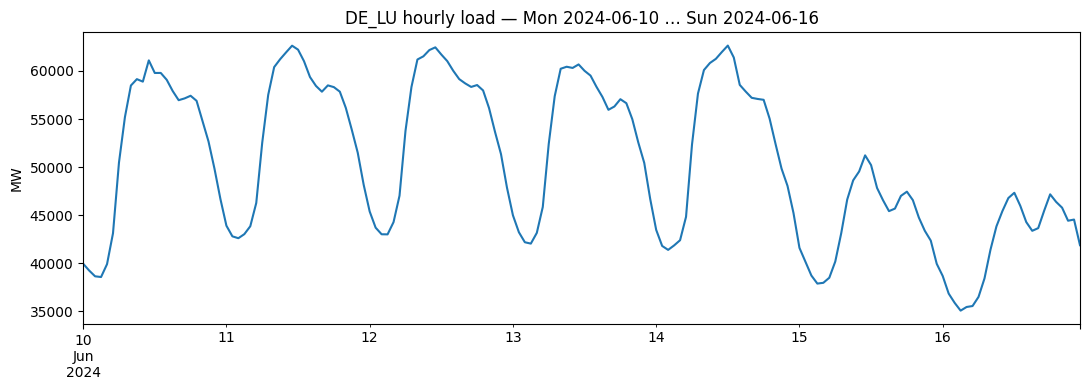

In [ ]:
import matplotlib.pyplot as plt

# --- zoom ---
PLOT_SCOPE = "week"  # "full" | "day" | "week"
PLOT_FOCUS_DATE = "2024-06-15"  # YYYY-MM-DD; used when PLOT_SCOPE is "day" or "week"

# --- only when PLOT_SCOPE == "full": smooth the whole series ---
PLOT_AGGREGATION = "weekly"  # "daily" or "weekly"

_tz = globals().get("TZ", "Europe/Berlin")

if PLOT_SCOPE == "full":
    _agg = {
        "daily": ("1D", "daily mean of hourly values"),
        "weekly": ("1W", "weekly mean of hourly values"),
    }
    if PLOT_AGGREGATION not in _agg:
        raise ValueError(f'PLOT_AGGREGATION must be one of {list(_agg)!r}.')
    freq, agg_label = _agg[PLOT_AGGREGATION]
    series_plot = load_hourly["load_mw"].resample(freq).mean() # This is a powerful pandas method that resamples time-series data. It groups the data into new time bins defined by freq (e.g., '1D' for daily, '1W' for weekly)
    title = f"{BIDDING_ZONE} actual total load — {agg_label}"
elif PLOT_SCOPE == "day":
    d0 = pd.Timestamp(PLOT_FOCUS_DATE, tz=_tz).normalize()
    d1 = d0 + pd.Timedelta(days=1)
    mask = (load_hourly.index >= d0) & (load_hourly.index < d1)
    series_plot = load_hourly.loc[mask, "load_mw"].sort_index()
    title = f"{BIDDING_ZONE} hourly load — {d0.date()}"
elif PLOT_SCOPE == "week":
    d = pd.Timestamp(PLOT_FOCUS_DATE, tz=_tz).normalize()
    week_start = d - pd.Timedelta(days=d.weekday())
    week_end = week_start + pd.Timedelta(days=7)
    mask = (load_hourly.index >= week_start) & (load_hourly.index < week_end)
    series_plot = load_hourly.loc[mask, "load_mw"].sort_index()
    week_sun = week_start + pd.Timedelta(days=6)
    title = (
        f"{BIDDING_ZONE} hourly load — Mon {week_start.date()} … Sun {week_sun.date()}"
    )
else:
    raise ValueError('PLOT_SCOPE must be "full", "day", or "week".')

if series_plot.empty:
    raise ValueError("No rows in range — check PLOT_FOCUS_DATE and data coverage.")

ax = series_plot.plot(figsize=(11, 4))
ax.set_title(title)
ax.set_ylabel("MW")
ax.set_xlabel("")
plt.tight_layout()
plt.show()